### 环境初始化

导入库

In [1]:
from typing import Sequence

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import OptimizeResult
import matplotlib.pyplot as plt
import scienceplots

环境配置

In [2]:
plt.rcParams.update({'figure.dpi': '600'})
plt.style.use(["science", "high-vis"])

工具函数

In [ ]:
def plot(sol: OptimizeResult, name: str, fmt: str = "pdf"):
    if len(sol.y) <= 1:
        plt.plot(sol.t, sol.y[0], label="x")
    else:
        for i, y in enumerate(sol.y):
            plt.plot(sol.t, y, label=f"$x_{i + 1}$")
        plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$x$")
    plt.savefig(f"../thesis/figures/{name}.{fmt}", format=fmt)
    plt.show()

### Logistic 增长模型

$$
\frac{\mathrm{d} x}{\mathrm{d} t} = r x (1 - \frac{x}{k})
$$

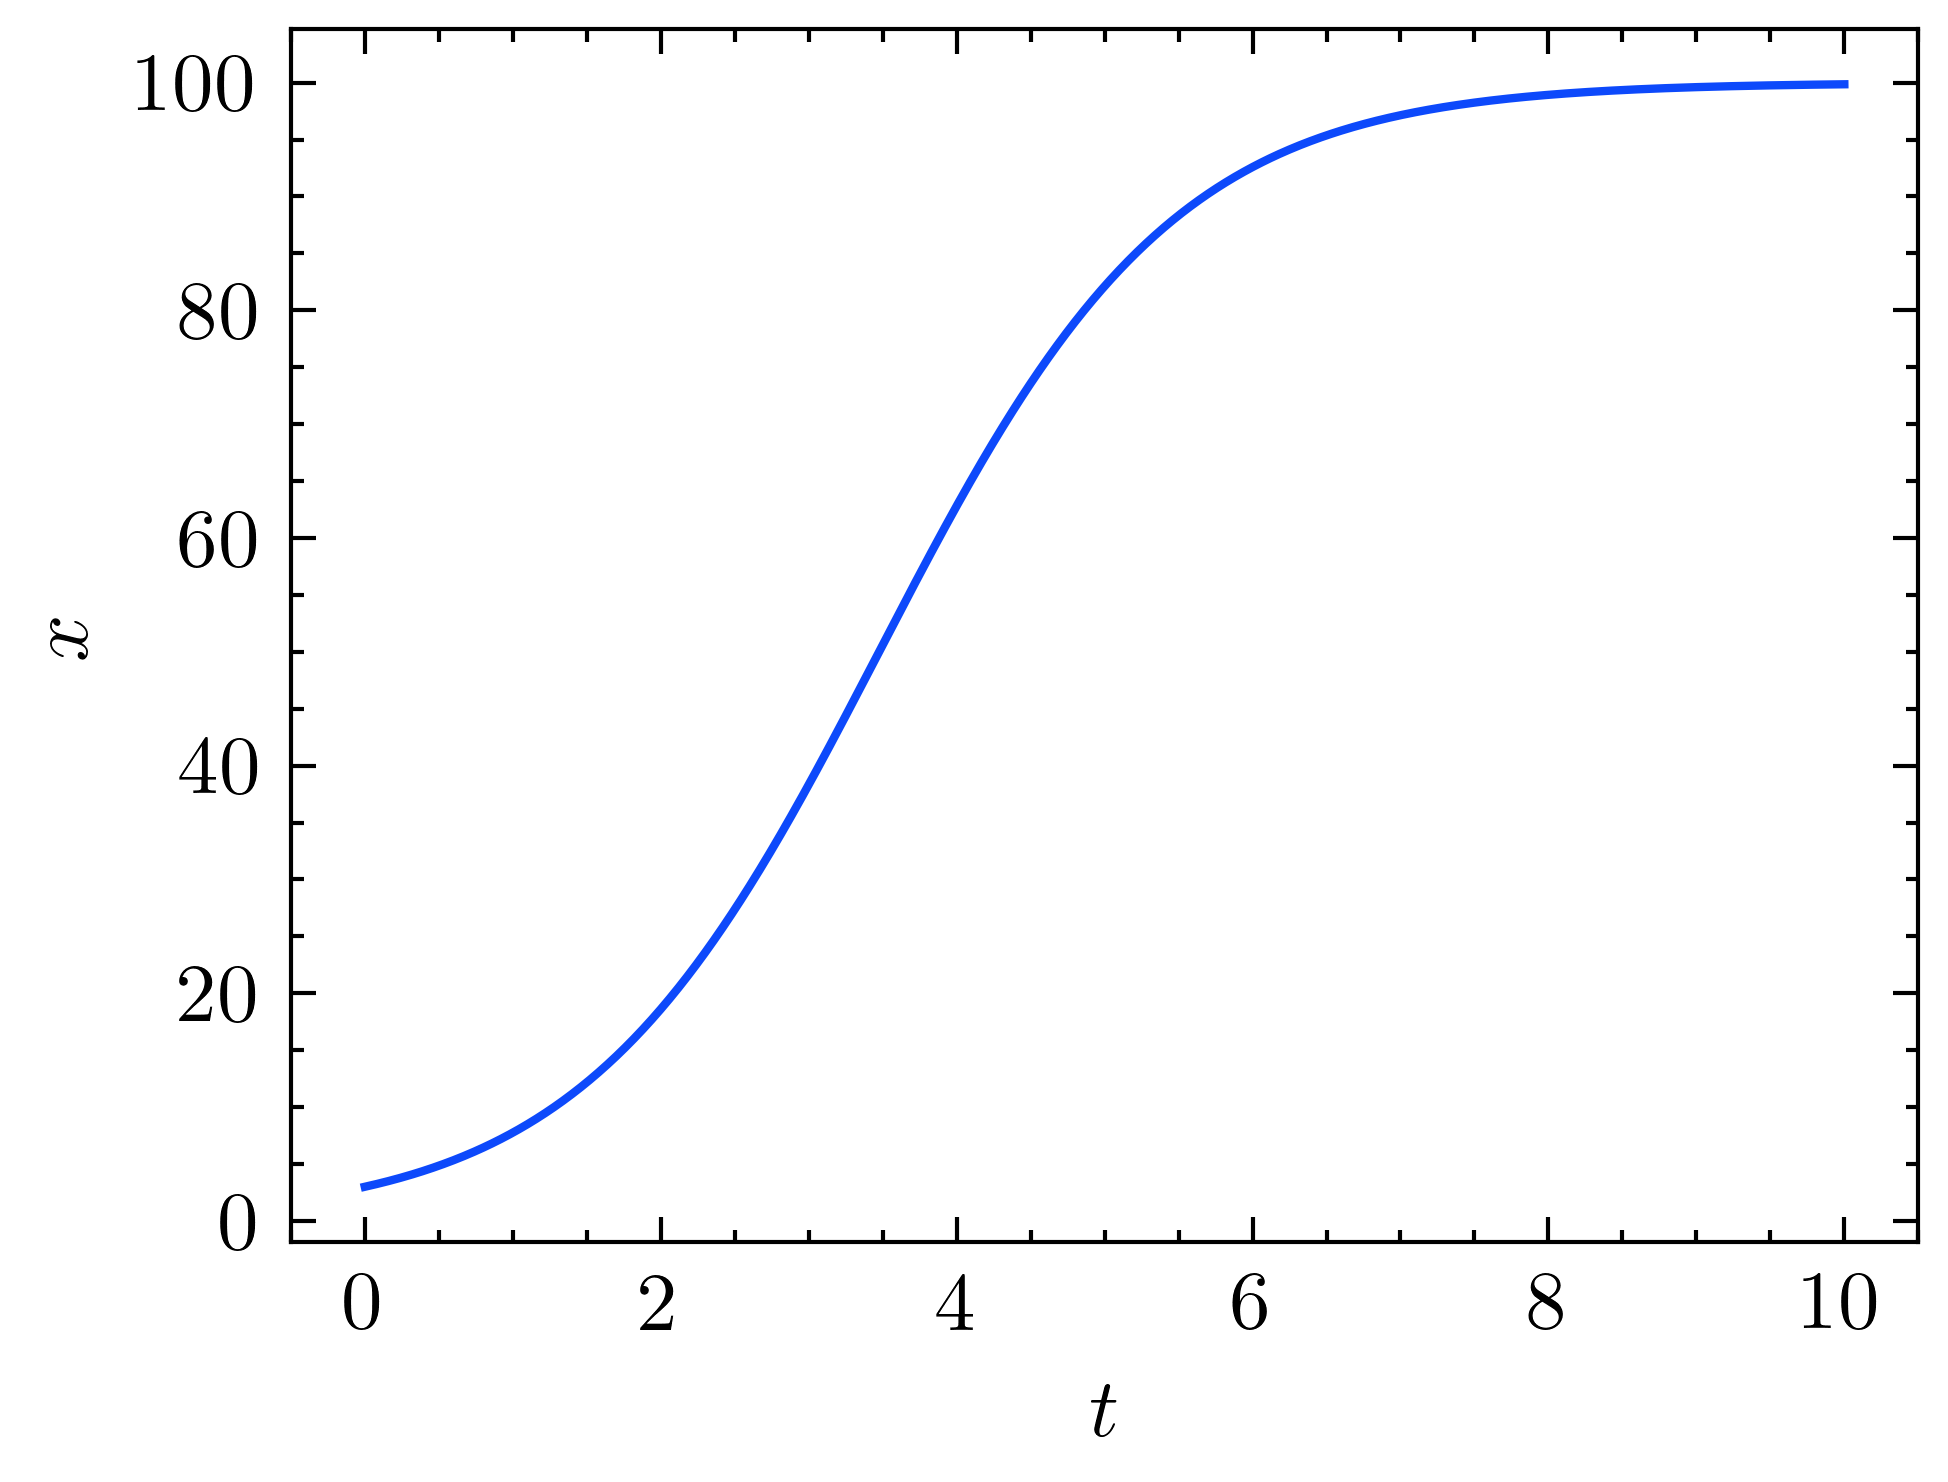

In [ ]:
logistic = lambda t, x, r, k: r * x * (1 - x / k)
t_span = (0, 10)
y0 = (3,)
r = 1
k = 100

sol = solve_ivp(logistic, t_span, y0, args=(r, k), max_step=0.01)
plot(sol, "logistic")

### Lotka-Volterra 竞争模型

$$
\frac{\mathrm{d} x_1}{\mathrm{d} t} = r_1 x_1 (1 - \frac{x_1}{k_1} - \alpha_{1,2} \frac{x_2}{k_1})
$$
$$
\frac{\mathrm{d} x_2}{\mathrm{d} t} = r_2 x_2 (1 - \frac{x_2}{k_2} - \alpha_{2,1} \frac{x_1}{k_2})
$$

$$
\frac{\mathrm{d} x_i}{\mathrm{d} t} = r_i x_i (1 - \frac{1}{k_i} \sum_{j} \alpha_{i,j} x_j)
$$
$$
\frac{\mathrm{d} \mathbf{x}}{\mathrm{d} t} = \mathbf{x} \circ (\mathbf{I} - \boldsymbol{\alpha} \mathbf{x})
$$

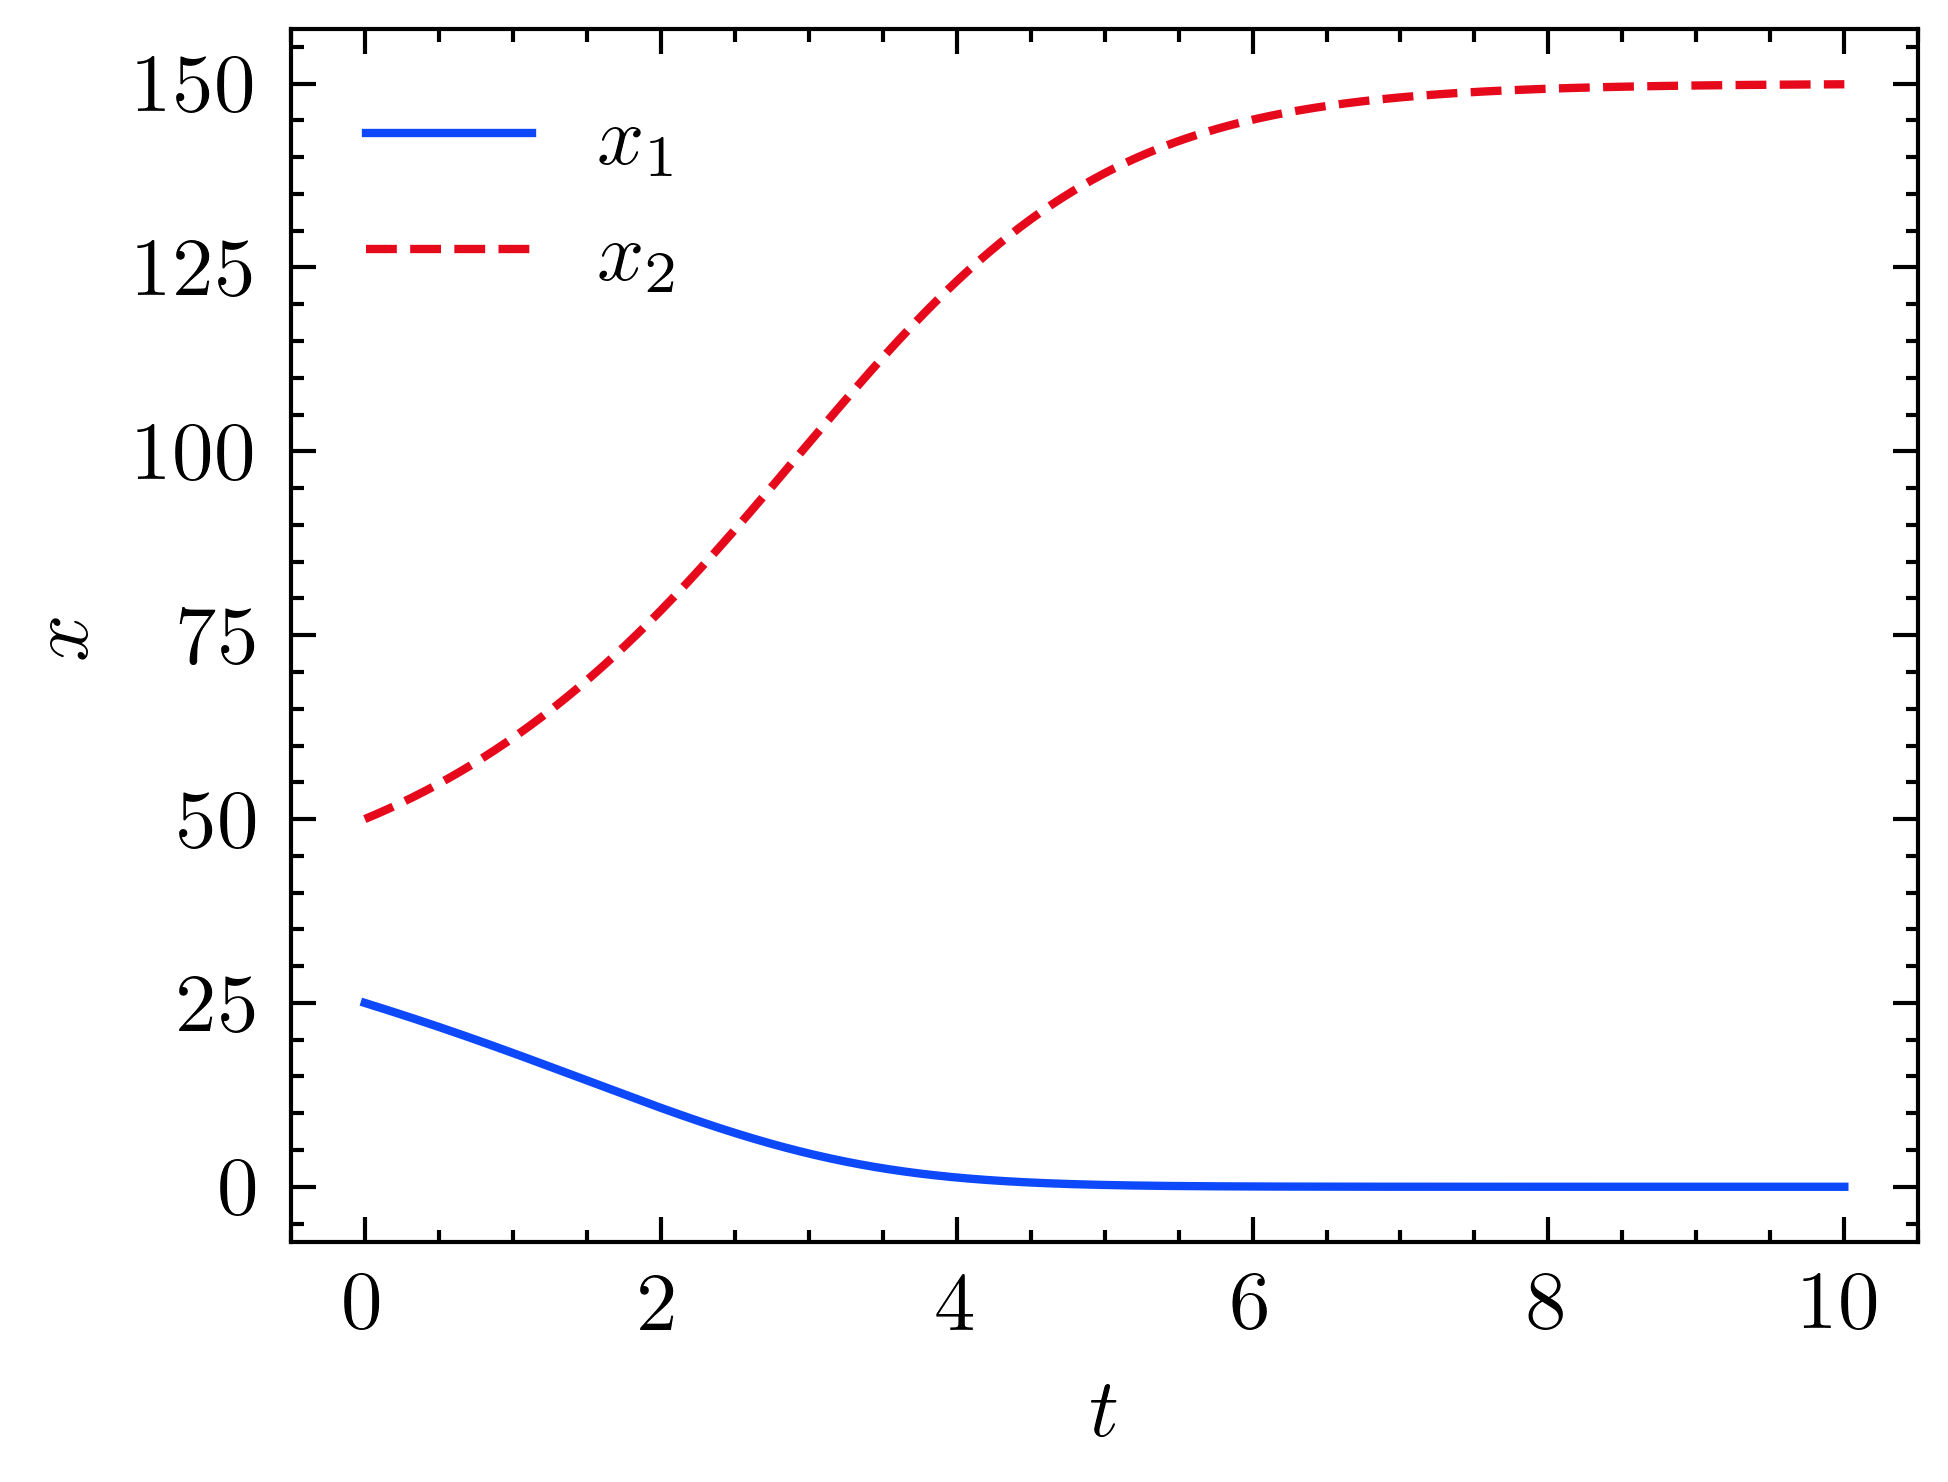

In [5]:
lvc = lambda t, x, r, k, alpha: r * x * (1 - alpha @ x / k)

t_span = (0, 10)
y0 = (25, 50)
r = (1, 1)
k = (100, 150)
alpha = (
    [1, 2],
    [3, 1]
)

sol = solve_ivp(lvc, t_span, y0, args=(r, k, alpha), max_step=0.01)
plot(sol, "lotka-volterra-competition")

### Lotka-Volterra 捕食模型

$$
\frac{\mathrm{d} x_1}{\mathrm{d} t} = x_1 (r_1 - \beta_{1,2} x_2)
$$
$$
\frac{\mathrm{d} x_2}{\mathrm{d} t} = x_2 (-r_2 + \beta_{2,1} x_1)
$$

$$
\frac{\mathrm{d} x_i}{\mathrm{d} t} = x_i (r_i + \sum_{j} \beta_{i,j} x_j)
$$
$$
\frac{\mathrm{d} \mathbf{x}}{\mathrm{d} t} = \mathbf{x} \circ (\mathbf{r} + \boldsymbol{\beta} \mathbf{x})
$$

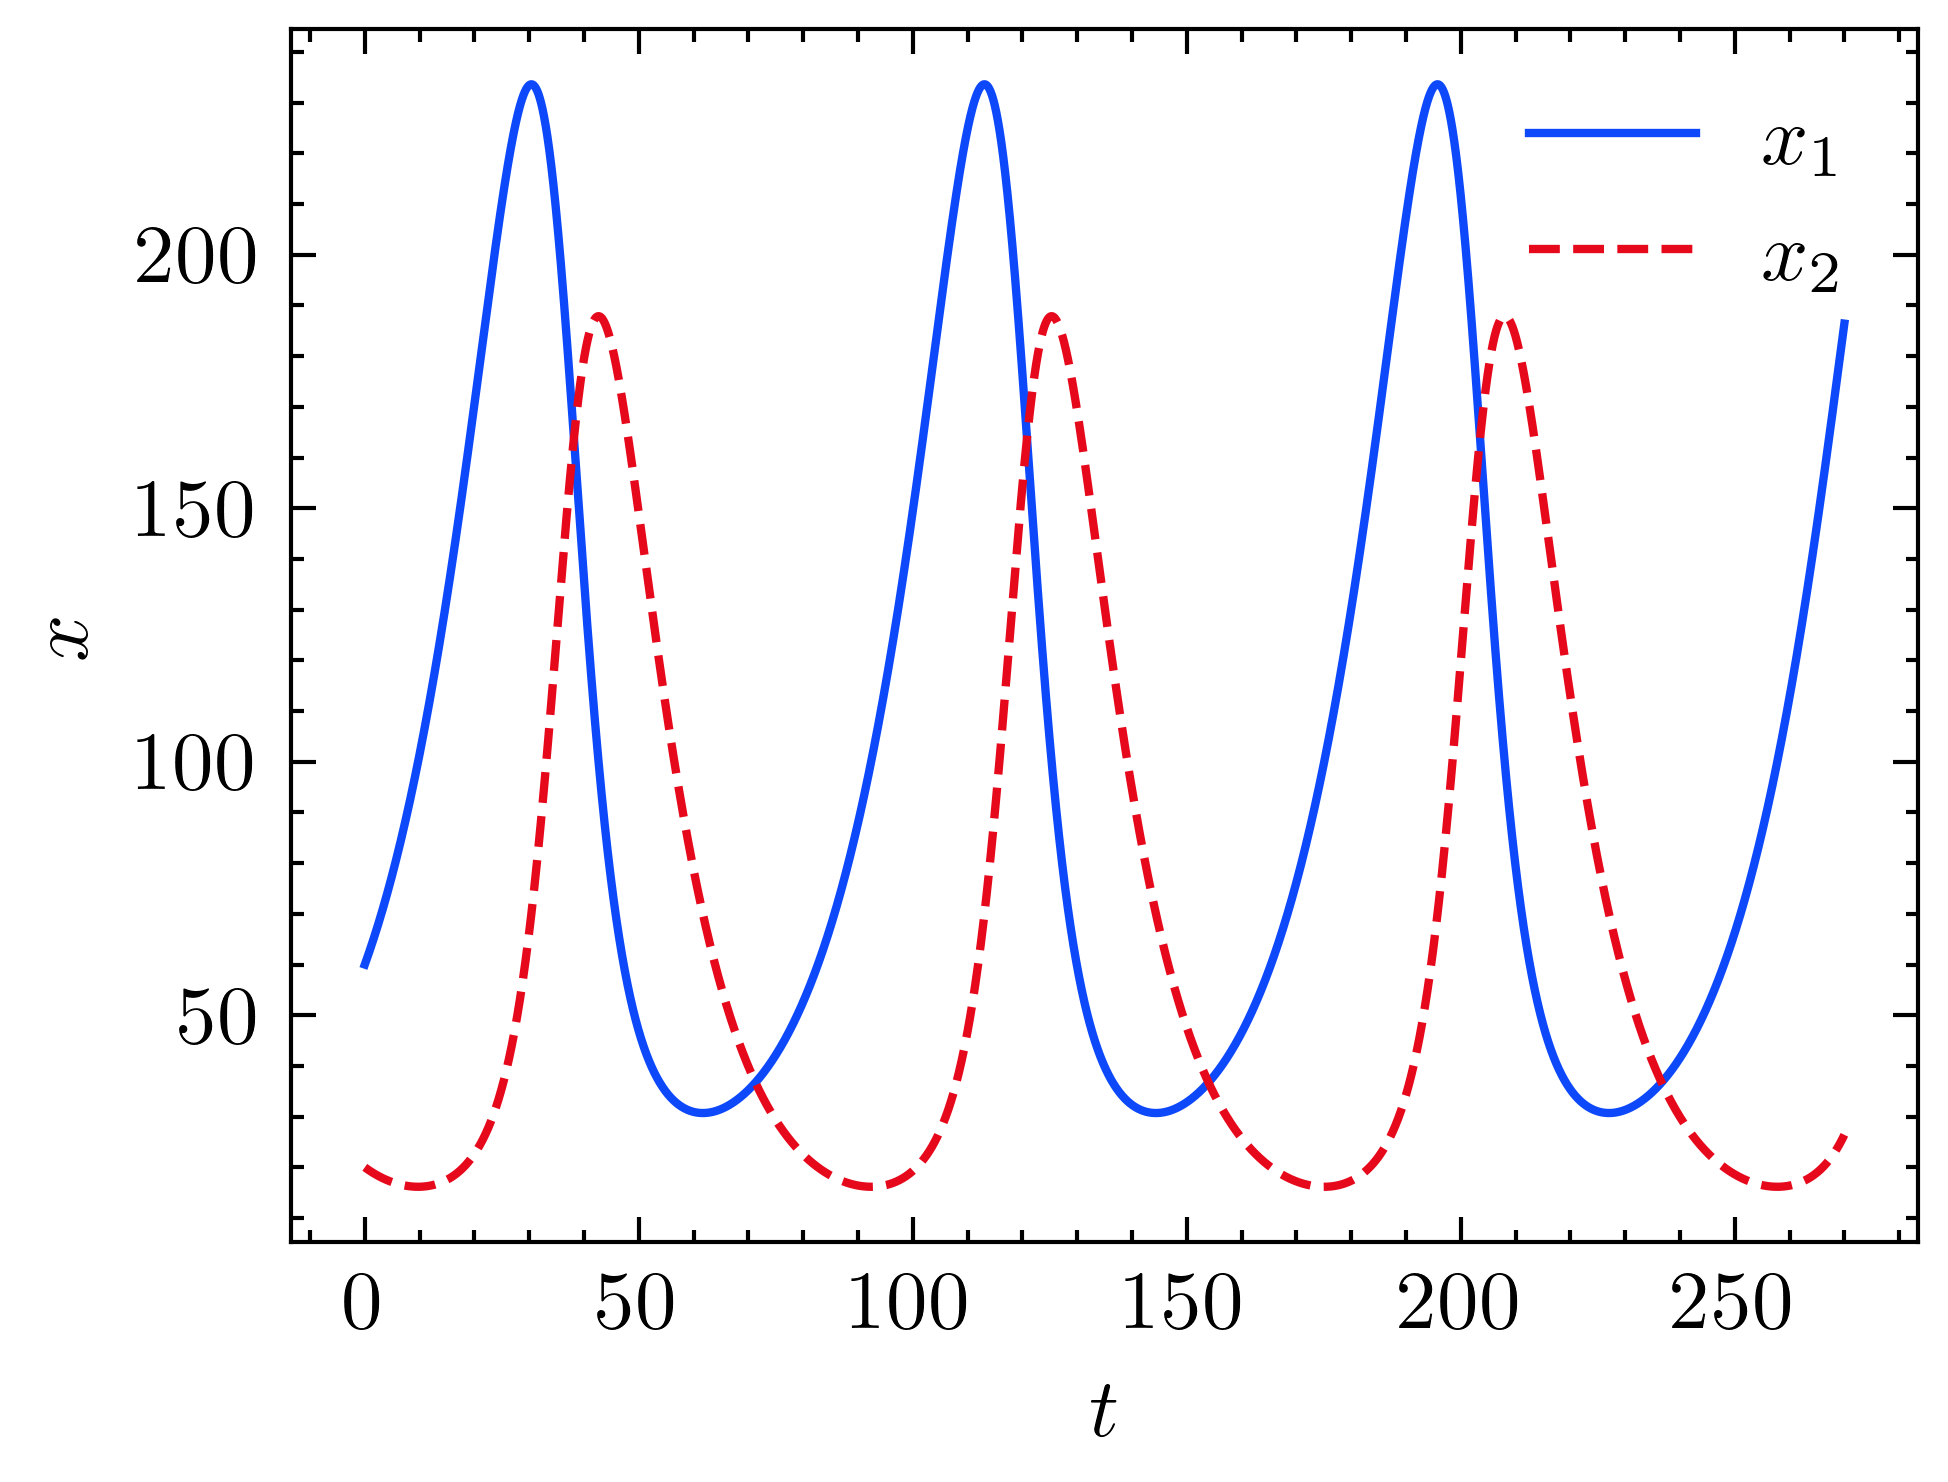

In [6]:
lvp = lambda t, x, r, beta: x * (r + beta @ x)

t_span = (0, 270)
y0 = (60, 20)
r = (0.07, -0.1)
beta = (
    [0, -0.001],
    [0.001, 0],
)

sol = solve_ivp(lvp, t_span, y0, args=(r, beta), max_step=0.01)
plot(sol, "lotka-volterra-predation")

### 综合模型

$$
\frac{\mathrm{d} x_i}{\mathrm{d} t} = x_i (1 - \frac{1}{k_i} \sum_{j} \alpha_{i,j} x_j) (r_i + \sum_{j} \beta_{i,j} x_j) + f_i(t)
$$
$$
\frac{\mathrm{d} \mathbf{x}}{\mathrm{d} t} = \mathbf{x} \circ (\mathbf{I} - \boldsymbol{\alpha} \mathbf{x}) \circ (\mathbf{r} + \boldsymbol{\beta} \mathbf{x}) + \mathbf{f}
$$

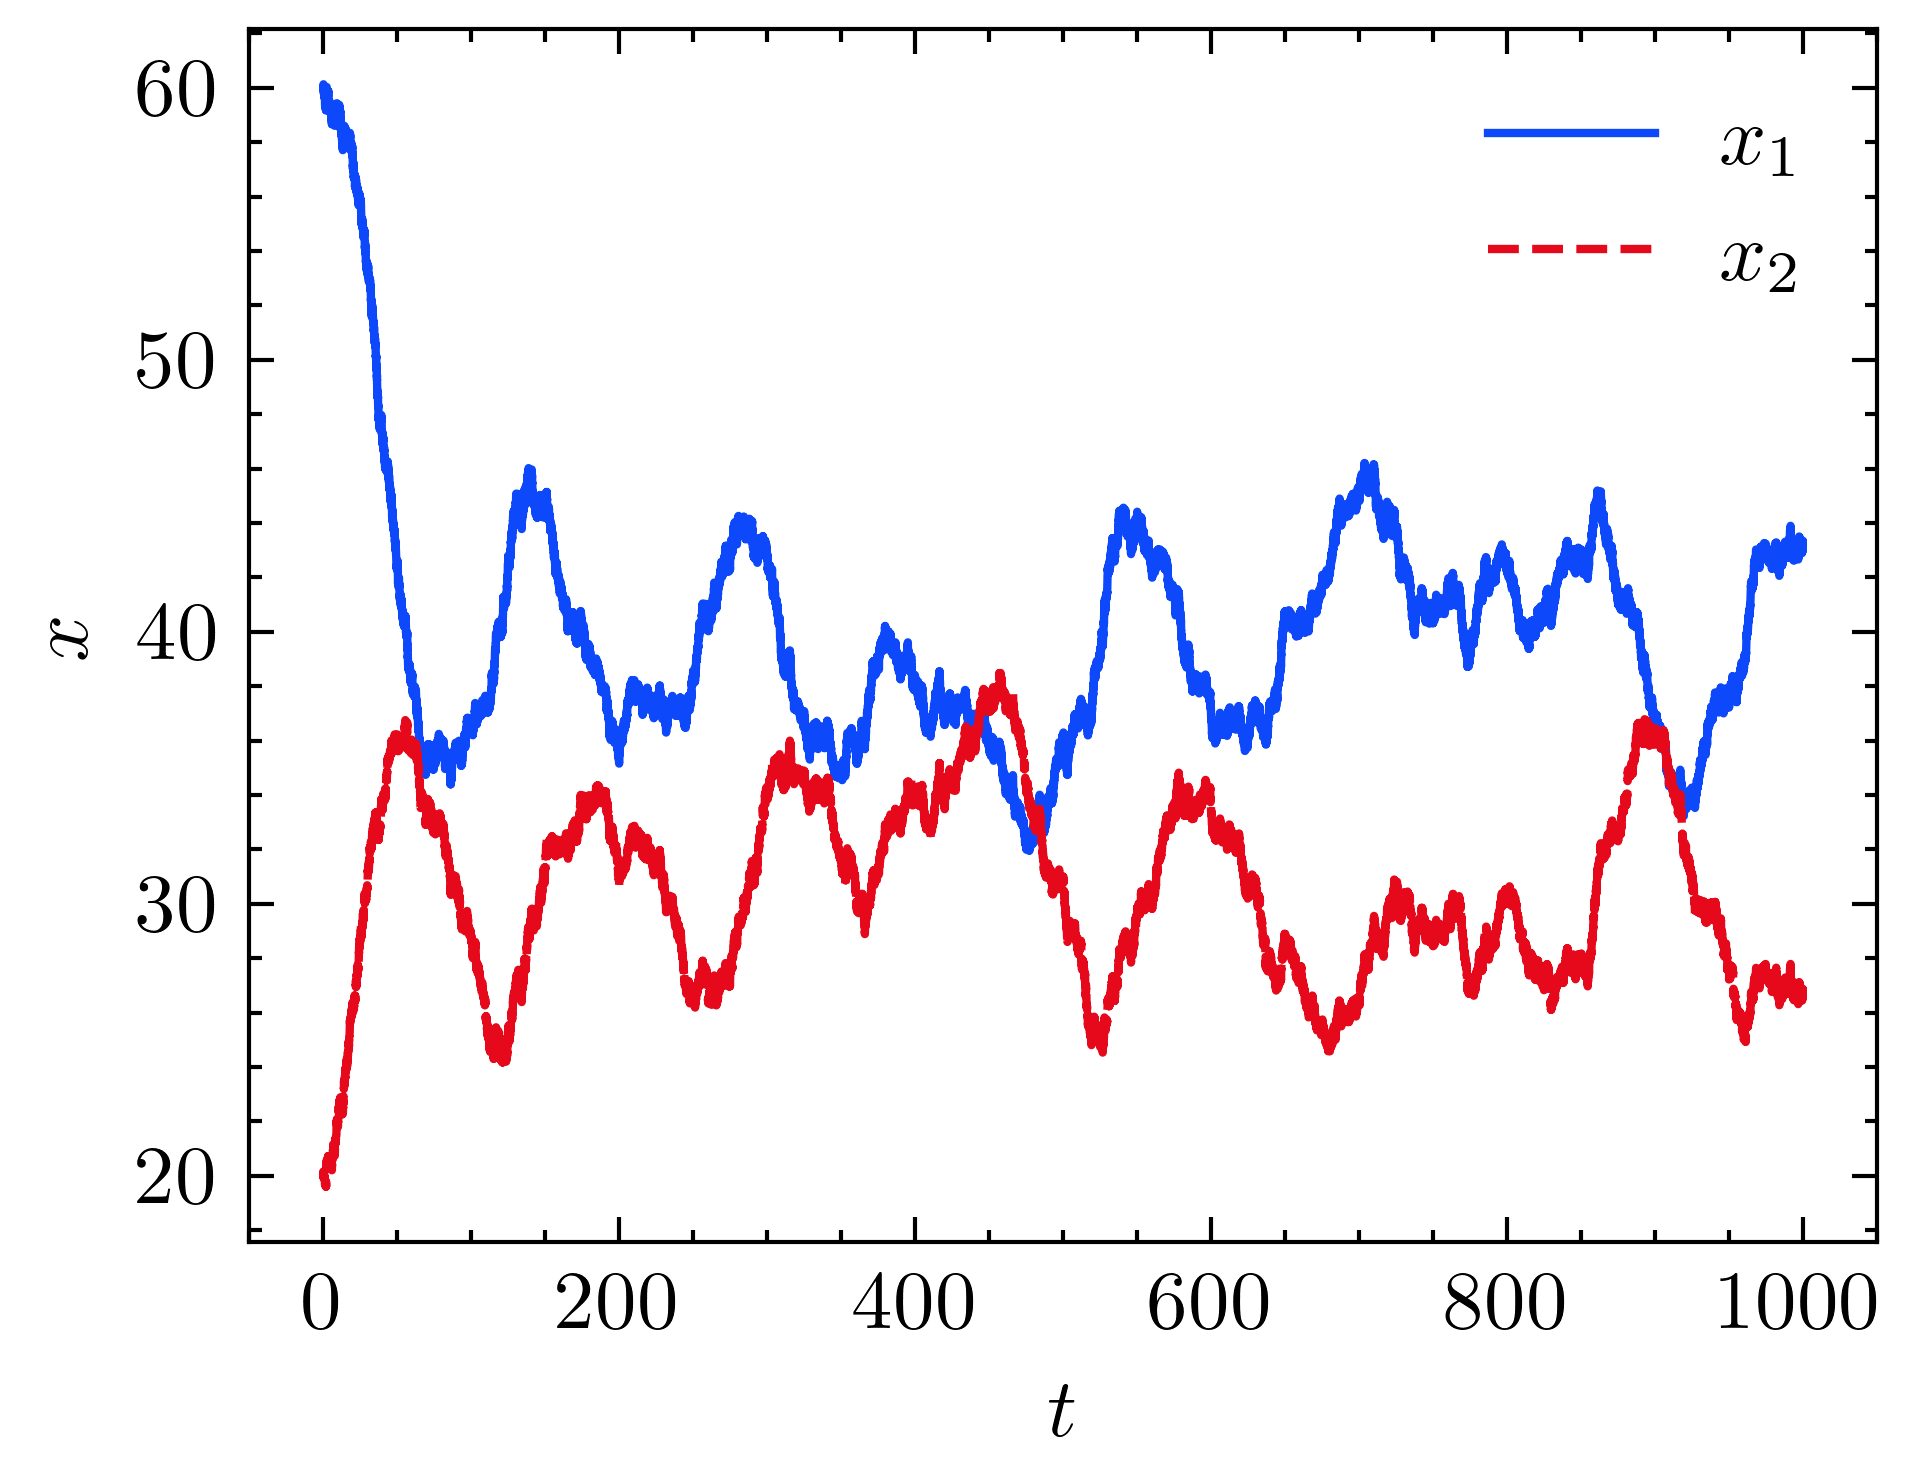

In [7]:
general = lambda t, x, r, k, alpha, beta, f: x * (1 - alpha @ x / k) * (r + beta @ x) + f(t)

# TODO: more data
t_span = (0, 1000)
y0 = (60, 20)
r = (0.1, -0.1)
k = (100, 150)
alpha = (
    [1, 2],
    [3, 1]
)
beta = (
    [0, -0.001],
    [0.001, 0],
)
f = lambda t: (np.random.normal() * 4,) * 2

sol = solve_ivp(general, t_span, y0, args=(r, k, alpha, beta, f), max_step=0.01)
plot(sol, "general")